# Step 1: Import Required Libraries

In [2]:
import pandas as pd

# Step 2: Load the CSV File

In [5]:
listings = pd.read_csv("Listings.csv", encoding='latin1')
print(listings.head())

C:\Users\Ishad\AppData\Local\Temp\ipykernel_30200\2992075426.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv("Listings.csv", encoding='latin1')


   listing_id                                              name   host_id  \
0      281420    Beautiful Flat in le Village Montmartre, Paris   1466919   
1     3705183                   39 mÃÂ² Paris (Sacre CÃâur)  10328771   
2     4082273               Lovely apartment with Terrace, 60m2  19252768   
3     4797344               Cosy studio (close to Eiffel tower)  10668311   
4     4823489  Close to Eiffel Tower - Beautiful flat : 2 rooms  24837558   

   host_since                 host_location host_response_time  \
0  2011-12-03  Paris, Ile-de-France, France                NaN   
1  2013-11-29  Paris, Ile-de-France, France                NaN   
2  2014-07-31  Paris, Ile-de-France, France                NaN   
3  2013-12-17  Paris, Ile-de-France, France                NaN   
4  2014-12-14  Paris, Ile-de-France, France                NaN   

   host_response_rate  host_acceptance_rate host_is_superhost  \
0                 NaN                   NaN                 f   
1         

In [6]:
listings['host_since'] = pd.to_datetime(
    listings['host_since'],
    errors='coerce'
)

In [7]:
paris_listings = listings[
    listings['city'].str.upper() == 'PARIS'
][[
    'host_since',
    'neighbourhood',
    'city',
    'accommodates',
    'price'
]]

In [8]:
print(paris_listings.head())

  host_since      neighbourhood   city  accommodates  price
0 2011-12-03  Buttes-Montmartre  Paris             2     53
1 2013-11-29  Buttes-Montmartre  Paris             2    120
2 2014-07-31             Elysee  Paris             2     89
3 2013-12-17          Vaugirard  Paris             2     58
4 2014-12-14              Passy  Paris             2     60


In [9]:
# Missing values
print("\nMissing Values:\n")
print(paris_listings.isnull().sum())

# Numeric summary
numeric_cols = paris_listings.select_dtypes(include=['number'])

summary = pd.DataFrame({
    'Minimum': numeric_cols.min(),
    'Maximum': numeric_cols.max(),
    'Average': numeric_cols.mean()
})

print("\nSummary:\n")
print(summary)


Missing Values:

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

Summary:

              Minimum  Maximum     Average
accommodates        0       16    3.037997
price               0    12000  113.096445


# Objective 2: Prepare the Data for Visualization 📊✨

# Step 1: Create paris_listings_neighbourhood

In [11]:
# Group by neighbourhood and calculate mean price
paris_listings_neighbourhood = (
    paris_listings
    .groupby('neighbourhood')['price']
    .mean()
    .sort_values()
    .reset_index()
)

# Display result
print(paris_listings_neighbourhood)

          neighbourhood       price
0          Menilmontant   74.942257
1       Buttes-Chaumont   82.690182
2     Buttes-Montmartre   87.209479
3               Reuilly   89.058402
4            Popincourt   90.559459
5              Gobelins   98.110184
6          Observatoire  101.866801
7   Batignolles-Monceau  102.612702
8     Enclos-St-Laurent  102.967156
9             Vaugirard  106.831330
10                Opera  119.038644
11             Pantheon  122.662150
12               Temple  138.446823
13       Hotel-de-Ville  144.472110
14               Bourse  149.496801
15           Luxembourg  155.638639
16       Palais-Bourbon  156.856578
17                Passy  161.144635
18               Louvre  175.379972
19               Elysee  210.536765


# Step 2: Find Most Expensive Neighbourhood 💸

In [12]:
# Find most expensive neighbourhood
most_expensive_neighbourhood = (
    paris_listings_neighbourhood
    .sort_values(by='price', ascending=False)
    .iloc[0]['neighbourhood']
)

print("Most Expensive Neighbourhood:")
print(most_expensive_neighbourhood)

Most Expensive Neighbourhood:
Elysee


# Step 3: Create paris_listings_accommodations

In [13]:
# Filter data for most expensive neighbourhood
paris_listings_accommodations = (
    paris_listings[
        paris_listings['neighbourhood'] == most_expensive_neighbourhood
    ]
    .groupby('accommodates')['price']
    .mean()
    .sort_index()
    .reset_index()
)

# Display result
print(paris_listings_accommodations)

    accommodates       price
0              0    0.000000
1              1   79.522222
2              2  155.103352
3              3  152.828767
4              4  212.096070
5              5  328.817073
6              6  355.508571
7              7  411.538462
8              8  405.518519
9              9  440.272727
10            10  500.857143
11            11  805.000000
12            12  529.625000
13            13  842.500000
14            14  971.000000
15            16  800.000000


# Step 4: Create paris_listings_over_time ⏳

In [14]:
# Create host year column
paris_listings['host_year'] = paris_listings['host_since'].dt.year

# Group by host year
paris_listings_over_time = (
    paris_listings
    .groupby('host_year')
    .agg({
        'price': 'mean',
        'host_since': 'count'
    })
    .rename(columns={
        'price': 'average_price',
        'host_since': 'new_hosts'
    })
    .reset_index()
)

# Display result
print(paris_listings_over_time)

    host_year  average_price  new_hosts
0      2008.0      77.750000          4
1      2009.0     159.641509        106
2      2010.0     125.031250        416
3      2011.0     124.828230       1339
4      2012.0     111.578615       4592
5      2013.0     107.096414       8142
6      2014.0     100.253800      10922
7      2015.0     103.646250      12147
8      2016.0     114.159847       8871
9      2017.0     108.658888       4585
10     2018.0     138.209362       4294
11     2019.0     129.757113       5694
12     2020.0     141.456038       3412
13     2021.0      93.488722        133


# Objective 3: Visualize the Data & Summarize Findings 📊🗼

# Before plotting, import visualization libraries:

In [16]:
import matplotlib.pyplot as plt

In [18]:
# 1. Horizontal Bar Chart
# Average Price by Neighbourhood

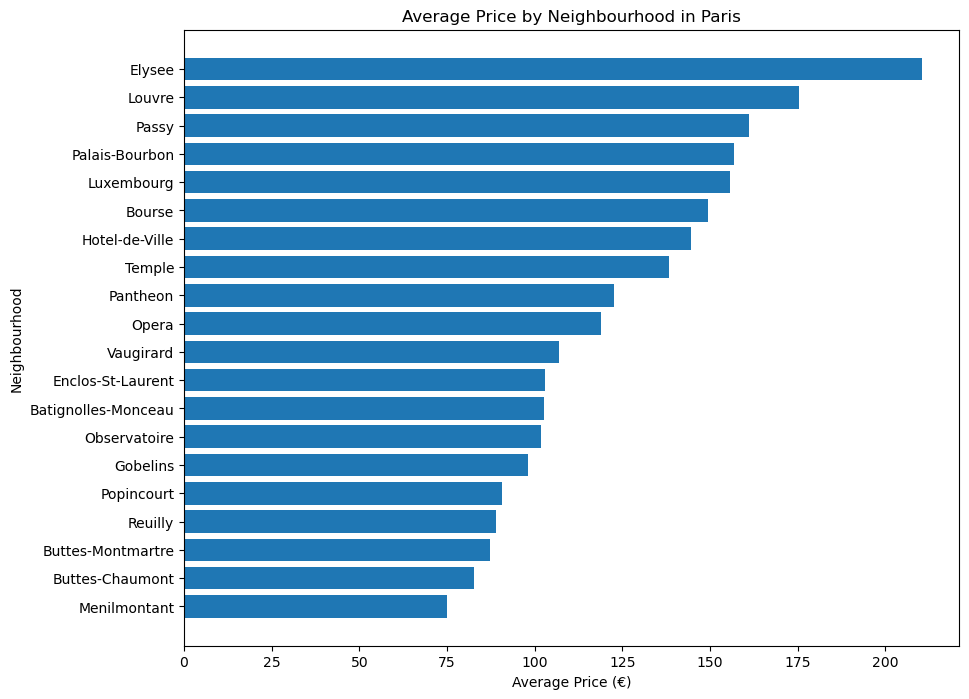

In [20]:
# Sort values for cleaner chart
paris_listings_neighbourhood = (
    paris_listings_neighbourhood
    .sort_values(by='price')
)

# Create figure
plt.figure(figsize=(10,8))

# Horizontal bar chart
plt.barh(
    paris_listings_neighbourhood['neighbourhood'],
    paris_listings_neighbourhood['price']
)

# Titles and labels
plt.title("Average Price by Neighbourhood in Paris")
plt.xlabel("Average Price (€)")
plt.ylabel("Neighbourhood")

# Show plot
plt.show()

# 2. Horizontal Bar Chart Average Price by Accommodates (Most Expensive Neighbourhood)

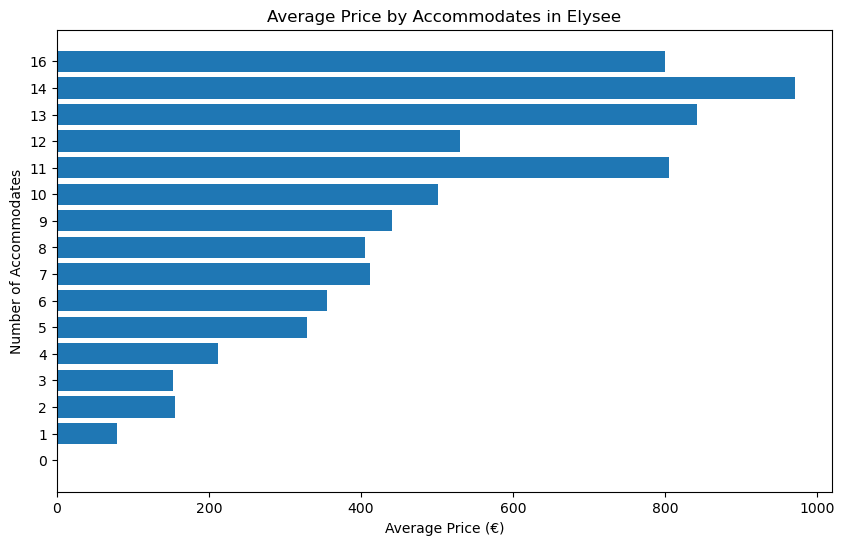

In [21]:
# Create figure
plt.figure(figsize=(10,6))

# Horizontal bar chart
plt.barh(
    paris_listings_accommodations['accommodates'].astype(str),
    paris_listings_accommodations['price']
)

# Titles and labels
plt.title(
    f"Average Price by Accommodates in {most_expensive_neighbourhood}"
)

plt.xlabel("Average Price (€)")
plt.ylabel("Number of Accommodates")

# Show plot
plt.show()

# 3. Line Chart Number of New Hosts Over Time

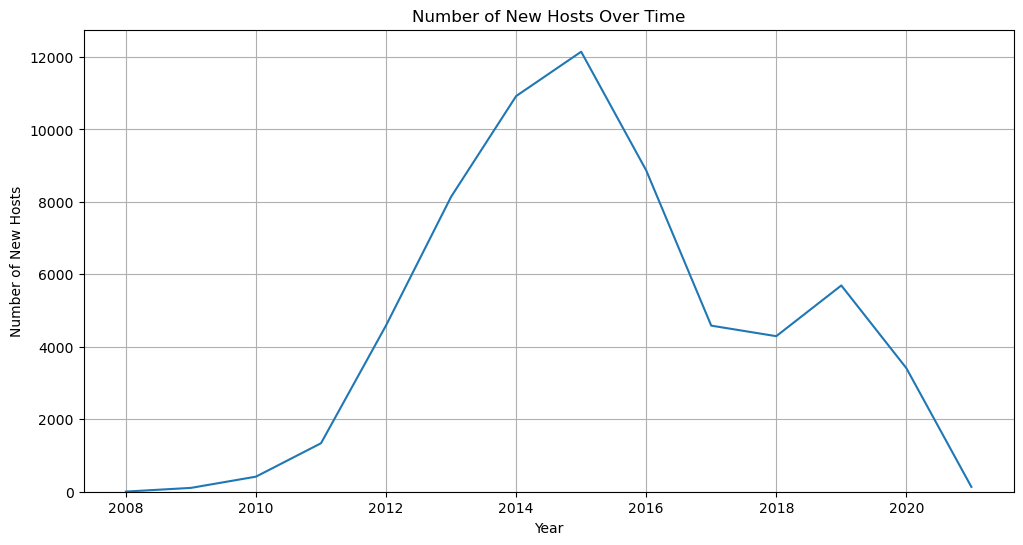

In [22]:
# Create figure
plt.figure(figsize=(12,6))

# Plot line
plt.plot(
    paris_listings_over_time['host_year'],
    paris_listings_over_time['new_hosts']
)

# Titles and labels
plt.title("Number of New Hosts Over Time")

plt.xlabel("Year")
plt.ylabel("Number of New Hosts")

# Set y-axis minimum
plt.ylim(0)

# Grid
plt.grid(True)

# Show plot
plt.show()

# 4. Line Chart Average Price Over Time

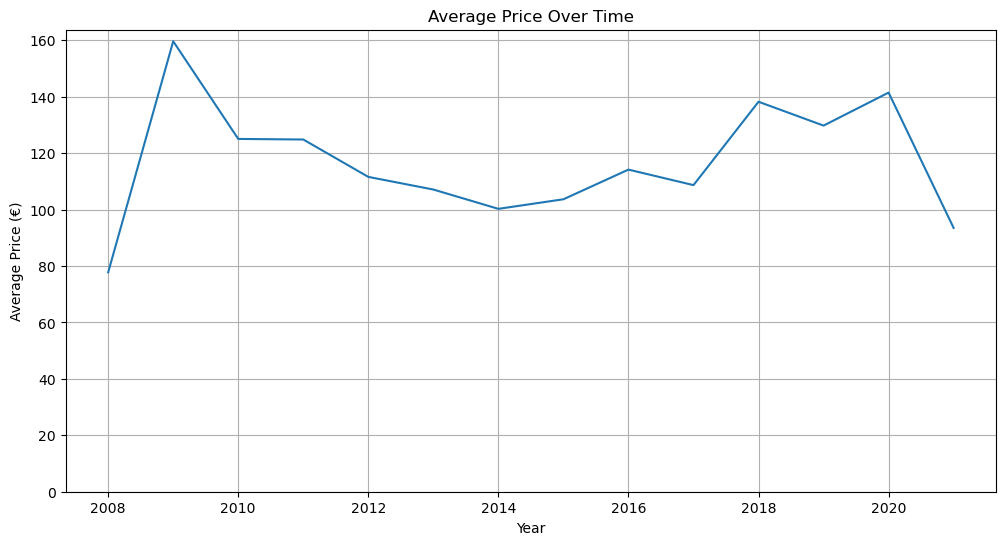

In [23]:
# Create figure
plt.figure(figsize=(12,6))

# Plot line
plt.plot(
    paris_listings_over_time['host_year'],
    paris_listings_over_time['average_price']
)

# Titles and labels
plt.title("Average Price Over Time")

plt.xlabel("Year")
plt.ylabel("Average Price (€)")

# Set y-axis minimum
plt.ylim(0)

# Grid
plt.grid(True)

# Show plot
plt.show()

# BONUS 🎁 Dual Axis Line Chart This combines: New hosts Average prices Into one cinematic dashboard 📡

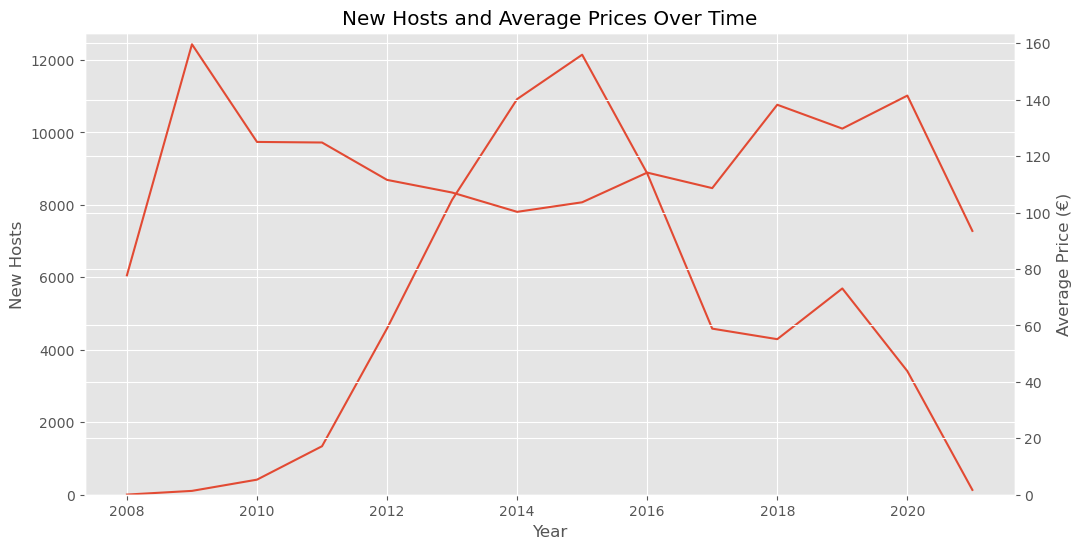

In [27]:
fig, ax1 = plt.subplots(figsize=(12,6))

# First axis
ax1.plot(
    paris_listings_over_time['host_year'],
    paris_listings_over_time['new_hosts']
)

ax1.set_xlabel("Year")
ax1.set_ylabel("New Hosts")

ax1.set_ylim(0)

# Second axis
ax2 = ax1.twinx()

ax2.plot(
    paris_listings_over_time['host_year'],
    paris_listings_over_time['average_price']
)

ax2.set_ylabel("Average Price (€)")
ax2.set_ylim(0)

# Title
plt.title("New Hosts and Average Prices Over Time")

# Show plot
plt.show()
plt.style.use('ggplot')

# Final Step Final Project Question Answer the following question to validate your completed project. Which neighborhood in Paris has the highest average AirBnB listing price?

In [28]:
print("The neighborhood with the highest average AirBnB listing price is:")

print(most_expensive_neighbourhood)

The neighborhood with the highest average AirBnB listing price is:
Elysee


In [29]:
most_expensive_neighbourhood

'Elysee'

In [30]:
print(
    f"The neighborhood with the highest average AirBnB listing price is {most_expensive_neighbourhood}."
)

The neighborhood with the highest average AirBnB listing price is Elysee.
